# Experiment 4: YOLO Object Detection

This notebook implements YOLO(`You only look once`) object detection based on the practical.
It includes:
- image inference (default, notebook-friendly)
- optional webcam inference loop (for local GUI environments)
        

In [3]:
!pip install numpy pandas matplotlib "ultralytics>=8.0" "opencv-python-headless>=4.8"
!pip install opencv-python-headless --force-reinstall

  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (60.4 MB)
Using cached numpy-2.4.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.request import urlretrieve
from ultralytics import YOLO


Downloaded sample image to: /home/jovyan/work/image.jpg



[W508 05:11:52.252951185 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W508 05:11:52.258053270 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


0: 640x480 4 persons, 1 bus, 1 stop sign, 2090.6ms
Speed: 22.9ms preprocess, 2090.6ms inference, 47.7ms postprocess per image at shape (1, 3, 640, 480)


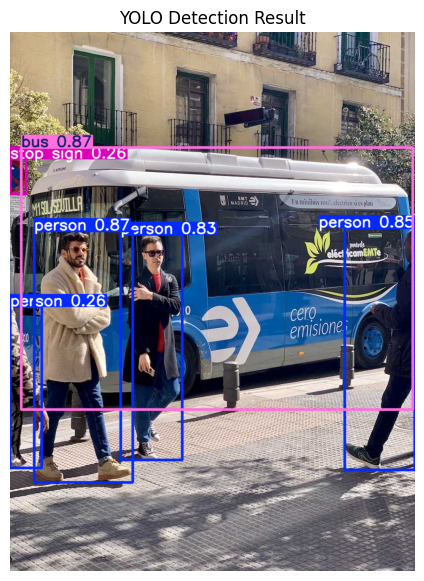

In [6]:
# Load pretrained YOLO model.
model = YOLO("yolov8n.pt")

# Use local image.jpg if present; otherwise download a sample image.
image_path = Path("image.jpg")
if not image_path.exists():
    sample_url = "https://ultralytics.com/images/bus.jpg"
    urlretrieve(sample_url, image_path)
    print(f"Downloaded sample image to: {image_path.resolve()}")

img = cv2.imread(str(image_path))
if img is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

results = model(img)
annotated = results[0].plot()

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLO Detection Result")
plt.show()
        

In [7]:
# Print detected objects and confidence.
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    print(f"Object: {model.names[cls_id]} | Confidence: {conf:.2f}")
        

Object: bus | Confidence: 0.87
Object: person | Confidence: 0.87
Object: person | Confidence: 0.85
Object: person | Confidence: 0.83
Object: person | Confidence: 0.26
Object: stop sign | Confidence: 0.26


In [8]:
# Optional: real-time webcam detection.
# Run this block only if your environment has webcam access and GUI display.
RUN_WEBCAM_DEMO = False

if RUN_WEBCAM_DEMO:
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        raise RuntimeError("Could not open webcam (index 0)")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        webcam_results = model(frame)
        annotated_frame = webcam_results[0].plot()
        cv2.imshow("YOLO Object Detection", annotated_frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()
        